# Лекция 3. Массивы: вектора и матрицы
Курс: Основы программирования
Язык: Julia
Среда: JupyterLab

## 0. Зачем нужны массивы

За смену сняли пять замеров напряжения. С тем, что мы знаем, их придётся хранить в пяти переменных:

In [1]:
U1 = 221
U2 = 218
U3 = 230
U4 = 215
U5 = 226

среднее = (U1 + U2 + U3 + U4 + U5) / 5

222.0

Для тысячи замеров так писать нельзя: тысяча имён, формула на несколько экранов, и цикл по таким переменным не пройти.

Нужна одна переменная, в которой лежит сразу весь набор значений, а к отдельному значению можно обратиться по номеру. Такая переменная называется **массивом**. Одномерный массив (ряд значений) — **вектор**, двумерный (таблица) — **матрица**.

## 1. Вектор

### 1.1 Создание

Вектор записывается в квадратных скобках, элементы разделяются запятыми.

In [2]:
U = [221, 218, 230, 215, 226]

5-element Vector{Int64}:
 221
 218
 230
 215
 226

In [3]:
length(U)

5

In [4]:
typeof(U)

Vector{Int64} (alias for Array{Int64, 1})

`length` — количество элементов. `typeof` показывает тип: `Vector{Int64}` — вектор, все элементы которого целые числа.

Все элементы вектора одного типа. Если смешать целые и дробные, Julia приведёт целые к дробным:

In [5]:
[1, 2.5, 3]

3-element Vector{Float64}:
 1.0
 2.5
 3.0

### 1.2 Индексы

К элементу обращаются по номеру (индексу) в квадратных скобках. Нумерация начинается с **1**.

In [6]:
U[1]

221

In [7]:
U[3]

230

In [8]:
U[end]

226

In [9]:
U[end - 1]

215

`end` внутри скобок означает номер последнего элемента. Он нужен, когда длина вектора заранее неизвестна.

Обращение к несуществующему номеру — ошибка:

In [10]:
U[6]

LoadError: BoundsError: attempt to access 5-element Vector{Int64} at index [6]

In [11]:
U[0]

LoadError: BoundsError: attempt to access 5-element Vector{Int64} at index [0]

### 1.3 Срезы

Вместо одного номера можно передать диапазон — получится новый вектор из выбранных элементов. Диапазоны те же, что в цикле `for`.

In [12]:
U[2:4]

3-element Vector{Int64}:
 218
 230
 215

In [13]:
U[1:2:end]

3-element Vector{Int64}:
 221
 230
 226

### 1.4 Изменение

Элементу можно присвоить новое значение:

In [14]:
U[4] = 220

220

In [15]:
U

5-element Vector{Int64}:
 221
 218
 230
 220
 226

`push!` добавляет элемент в конец, `pop!` убирает последний и возвращает его.

In [16]:
push!(U, 224)

6-element Vector{Int64}:
 221
 218
 230
 220
 226
 224

In [17]:
pop!(U)

224

In [18]:
U

5-element Vector{Int64}:
 221
 218
 230
 220
 226

Восклицательный знак в имени функции — соглашение Julia: функция с `!` изменяет переданный ей массив.

Частый приём — накопитель: пустой вектор создаётся до цикла, в цикле в него добавляются результаты. `Float64[]` — пустой вектор для дробных чисел.

In [20]:
R = 10              # сопротивление, Ом
P = Float64[]       # пустой вектор для мощностей

for I in 1:5
    push!(P, I^2 * R)
end

P

5-element Vector{Float64}:
  10.0
  40.0
  90.0
 160.0
 250.0

### 1.5 Готовые заготовки

In [22]:
zeros(5)

5-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0

In [23]:
ones(3)

3-element Vector{Float64}:
 1.0
 1.0
 1.0

In [24]:
fill(220, 4)

4-element Vector{Int64}:
 220
 220
 220
 220

Диапазон `1:5` сам по себе не вектор: он хранит только начало, шаг и конец. `collect` превращает его в вектор со всеми значениями:

In [25]:
1:5

1:5

In [26]:
collect(1:5)

5-element Vector{Int64}:
 1
 2
 3
 4
 5

In [27]:
collect(0:0.5:2)

5-element Vector{Float64}:
 0.0
 0.5
 1.0
 1.5
 2.0

### 1.6 Присваивание и копия

Числа ведут себя привычно: `y = x` кладёт в `y` то же значение, дальше переменные живут отдельно. С массивами есть отличие.

In [28]:
x = [1, 2, 3]
y = x
x = [7, 8, 9]

y

3-element Vector{Int64}:
 1
 2
 3

In [29]:
x = [1, 2, 3]
y = x
x[1] = 100

y

3-element Vector{Int64}:
 100
   2
   3

Массив можно представить коробкой, а имя — ярлыком на ней:

| Действие | Что происходит |
|---|---|
| `y = x` | на ту же коробку вешается второй ярлык |
| `x = [7, 8, 9]` | создаётся новая коробка, ярлык `x` переклеивается на неё |
| `x[1] = 100` | меняется содержимое коробки, на которой висят оба ярлыка |

Если нужен независимый массив с теми же значениями, его создают через `copy`:

In [30]:
x = [1, 2, 3]
y = copy(x)
x[1] = 100

y

3-element Vector{Int64}:
 1
 2
 3

### 1.7 Обход циклом

Цикл `for` проходит не только по диапазону, но и по вектору: переменная цикла по очереди принимает значения элементов.

In [31]:
U = [221, 218, 230, 215, 226]

for u in U
    println(u)
end

221
218
230
215
226


Если кроме значения нужен его номер, цикл идёт по диапазону номеров:

In [32]:
for i in 1:length(U)
    println(i, "\t", U[i])
end

1	221
2	218
3	230
4	215
5	226


Поиск наибольшего замера и его номера — тот же приём, что в лекции 2, только данные теперь берутся из вектора:

In [33]:
U_макс = U[1]
номер = 1

for i in 2:length(U)
    if U[i] > U_макс
        U_макс = U[i]
        номер = i
    end
end

println("Наибольший замер: ", U_макс, " В, номер ", номер)

Наибольший замер: 230 В, номер 3


### 1.8 Поэлементные операции

Дан ток при каждом замере. Мощность в каждый момент — произведение напряжения и тока **с тем же номером**. Для поэлементной операции перед знаком ставится точка:

In [34]:
I = [1.25, 0.75, 2.5, 2.0, 0.5]   # ток, А

5-element Vector{Float64}:
 1.25
 0.75
 2.5
 2.0
 0.5

In [35]:
P = U .* I

5-element Vector{Float64}:
 276.25
 163.5
 575.0
 430.0
 113.0

Умножение вектора на число работает и без точки. Возведение в степень без точки — ошибка: для векторов `^` не определено.

In [36]:
U * 2

5-element Vector{Int64}:
 442
 436
 460
 430
 452

In [37]:
U .^ 2

5-element Vector{Int64}:
 48841
 47524
 52900
 46225
 51076

In [45]:
U ^ 2 

LoadError: MethodError: no method matching ^(::Vector{Int64}, ::Int64)
The function `^` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  ^([91m::Irrational{:ℯ}[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90m[4mmathconstants.jl:139[24m[39m
[0m  ^([91m::BigInt[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90m[4mgmp.jl:649[24m[39m
[0m  ^([91m::Float64[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90m[4mmath.jl:1197[24m[39m
[0m  ...


Точку можно поставить и после имени функции — функция применится к каждому элементу:

In [46]:
sqrt.(U)

5-element Vector{Float64}:
 14.866068747318506
 14.7648230602334
 15.165750888103101
 14.66287829861518
 15.033296378372908

In [47]:
round.(sqrt.(U), digits = 2)

5-element Vector{Float64}:
 14.87
 14.76
 15.17
 14.66
 15.03

Отклонение каждого замера от номинала 220 В в процентах — одной строкой:

In [48]:
round.((U .- 220) ./ 220 .* 100, digits = 2)

5-element Vector{Float64}:
  0.45
 -0.91
  4.55
 -2.27
  2.73

Сравнение с точкой даёт вектор из `true` и `false` — ответ для каждого элемента. Julia печатает его как `1` и `0`:

In [53]:
U .> 225

5-element BitVector:
 0
 0
 1
 0
 1

### 1.9 Встроенные функции

In [54]:
sum(U)

1110

In [55]:
maximum(U)

230

In [56]:
minimum(U)

215

In [57]:
argmax(U)

3

In [58]:
argmin(U)

4

In [59]:
sum(U) / length(U)

222.0

In [60]:
count(U .> 225)

2

Цикл поиска максимума из пункта 1.7 заменяется двумя вызовами: `maximum(U)` и `argmax(U)`. Среднее — `sum(U) / length(U)`. `count` считает, сколько `true` в векторе сравнения.

Сортировка есть в двух вариантах:

In [61]:
sort(U)

5-element Vector{Int64}:
 215
 218
 221
 226
 230

In [62]:
U

5-element Vector{Int64}:
 221
 218
 230
 215
 226

In [63]:
reverse(U)

5-element Vector{Int64}:
 226
 215
 230
 218
 221

In [64]:
sort!(U)

5-element Vector{Int64}:
 215
 218
 221
 226
 230

In [65]:
U

5-element Vector{Int64}:
 215
 218
 221
 226
 230

`sort` возвращает новый вектор, `sort!` переставляет элементы в самом `U`. Вместе с пунктом 1.6 это даёт ошибку:

In [66]:
U = [221, 218, 230, 215, 226]

U_сорт = U          # отсортированный вариант для медианы
sort!(U_сорт)

println("Медиана: ", U_сорт[3])
println("Первый замер: ", U[1])

Медиана: 221
Первый замер: 215


Ожидали первым замером 221, получили 215: `U_сорт` и `U` — один массив, и `sort!` переставил его. Исправление — `U_сорт = copy(U)` или `U_сорт = sort(U)`.

### 1.10 Отбор по условию

Вектор из `true`/`false` можно подставить в квадратные скобки: останутся элементы, напротив которых стоит `true`.

In [67]:
U[U .> 225]

2-element Vector{Int64}:
 226
 230

## 2. Строки

С первой лекции мы пишем текст в кавычках внутри `println`. Это тоже значение отдельного типа — строка.

In [68]:
typeof("220")

String

In [69]:
typeof(220)

Int64

In [70]:
"220" + 1

LoadError: MethodError: no method matching +(::String, ::Int64)
The function `+` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  +(::Any, ::Any, [91m::Any[39m, [91m::Any...[39m)
[0m[90m   @[39m [90mBase[39m [90m[4moperators.jl:596[24m[39m
[0m  +([91m::Base.CoreLogging.LogLevel[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90mlogging\[39m[90m[4mlogging.jl:134[24m[39m
[0m  +([91m::Complex{Bool}[39m, ::Real)
[0m[90m   @[39m [90mBase[39m [90m[4mcomplex.jl:323[24m[39m
[0m  ...


`"220"` — текст из трёх символов, а не число. Складывать его с числом нельзя.

Строки склеиваются знаком `*`. `string(...)` собирает строку из нескольких значений любого типа. Подстановку `$` вы уже знаете.

In [71]:
фаза = "A"

"A"

In [72]:
"Фаза " * фаза

"Фаза A"

In [73]:
string("U = ", 220, " В")

"U = 220 В"

In [74]:
"Фаза $фаза"

"Фаза A"

Строку можно положить в переменную и сравнить через `==`. Сравнение учитывает регистр: `"Норма"` и `"норма"` — разные строки.

In [75]:
P = 1350        # мощность, Вт
P_доп = 1200    # допустимая мощность, Вт

if P > P_доп
    режим = "перегрузка"
else
    режим = "норма"
end

println("Режим: ", режим)

Режим: перегрузка


In [78]:
режим == "перегрузка"

true

In [79]:
режим == "Перегрузка"

false

Массив может хранить строки:

In [80]:
фазы = ["A", "B", "C"]

3-element Vector{String}:
 "A"
 "B"
 "C"

In [81]:
фазы[2]

"B"

In [82]:
for ф in фазы
    println("Фаза ", ф)
end

Фаза A
Фаза B
Фаза C


## 3. Матрицы

### 3.1 Создание

Токи по трём фазам сняли четыре раза — через каждый час. Такие данные записывают таблицей: строка — час, столбец — фаза. Элементы строки разделяются пробелами, строки — точкой с запятой.

In [83]:
I = [10.5  11.25  9.75;
     12.0  12.5   11.0;
     14.25 13.75  15.5;
     11.5  12.25  10.75]

4×3 Matrix{Float64}:
 10.5   11.25   9.75
 12.0   12.5   11.0
 14.25  13.75  15.5
 11.5   12.25  10.75

In [84]:
size(I)

(4, 3)

In [85]:
size(I, 1)

4

In [86]:
size(I, 2)

3

In [87]:
length(I)

12

`size(I)` возвращает размеры: строк и столбцов. `size(I, 1)` — только число строк, `size(I, 2)` — только число столбцов. `length` — общее число элементов.

Запятая и пробел в квадратных скобках дают разные объекты:

In [88]:
[1, 2, 3]

3-element Vector{Int64}:
 1
 2
 3

In [89]:
[1 2 3]

1×3 Matrix{Int64}:
 1  2  3

### 3.2 Индексы

У элемента матрицы два номера: строка и столбец.

In [90]:
I[2, 3]

11.0

In [91]:
I[end, end]

10.75

Двоеточие на месте номера означает «все». `I[2, :]` — вся строка 2 (все фазы во втором часу), `I[:, 1]` — весь столбец 1 (фаза A за все часы).

In [92]:
I[2, :]

3-element Vector{Float64}:
 12.0
 12.5
 11.0

In [93]:
I[:, 1]

4-element Vector{Float64}:
 10.5
 12.0
 14.25
 11.5

In [94]:
I[1:2, 2:3]

2×2 Matrix{Float64}:
 11.25   9.75
 12.5   11.0

Изменение элемента — присваиванием. Чтобы не испортить исходные данные, работаем с копией:

In [95]:
I2 = copy(I)
I2[3, 2] = 14.0

I2[3, :]

3-element Vector{Float64}:
 14.25
 14.0
 15.5

### 3.3 Заготовки

In [96]:
zeros(3, 4)

3×4 Matrix{Float64}:
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0

In [97]:
fill(220, 2, 3)

2×3 Matrix{Int64}:
 220  220  220
 220  220  220

### 3.4 Обход вложенным циклом

Чтобы пройти все элементы, нужны два вложенных цикла: внешний по строкам, внутренний по столбцам. Шапку таблицы берём из вектора строк:

In [98]:
фазы = ["A", "B", "C"]

print("Час")
for ф in фазы
    print("\t", ф)
end
println()

for i in 1:size(I, 1)
    print(i)
    for j in 1:size(I, 2)
        print("\t", I[i, j])
    end
    println()
end

Час	A	B	C
1	10.5	11.25	9.75
2	12.0	12.5	11.0
3	14.25	13.75	15.5
4	11.5	12.25	10.75


### 3.5 Поэлементные операции

Точка работает с матрицами так же, как с векторами. Мощность по каждой фазе в каждый час, кВт:

In [99]:
P = 220 .* I ./ 1000

4×3 Matrix{Float64}:
 2.31   2.475  2.145
 2.64   2.75   2.42
 3.135  3.025  3.41
 2.53   2.695  2.365

In [100]:
count(I .> 12)

5

### 3.6 Суммы по строкам и столбцам

In [101]:
sum(I)

145.0

In [102]:
maximum(I)

15.5

`dims` задаёт направление: `dims = 1` — сложить вдоль столбца (по всем часам, итог для каждой фазы), `dims = 2` — вдоль строки (по всем фазам, итог для каждого часа).

In [103]:
sum(I, dims = 1)

1×3 Matrix{Float64}:
 48.25  49.75  47.0

In [104]:
sum(I, dims = 2)

4×1 Matrix{Float64}:
 31.5
 35.5
 43.5
 34.5

Результат — матрица из одной строки или одного столбца. Если нужен обычный вектор, его получают через `vec`:

In [105]:
vec(sum(I, dims = 2))

4-element Vector{Float64}:
 31.5
 35.5
 43.5
 34.5

### 3.7 Транспонирование

In [106]:
I'

3×4 adjoint(::Matrix{Float64}) with eltype Float64:
 10.5   12.0  14.25  11.5
 11.25  12.5  13.75  12.25
  9.75  11.0  15.5   10.75

### 3.8 Матричное умножение

До сих пор все операции были поэлементными. Операции без точки над матрицами — это операции линейной алгебры.

In [107]:
A = [1 2; 3 4]

2×2 Matrix{Int64}:
 1  2
 3  4

In [108]:
B = [0 1; 1 0]

2×2 Matrix{Int64}:
 0  1
 1  0

In [109]:
A .* B

2×2 Matrix{Int64}:
 0  2
 3  0

In [110]:
A * B

2×2 Matrix{Int64}:
 2  1
 4  3

`A .* B` перемножает элементы с одинаковыми номерами. `A * B` — матричное произведение: элемент `[i, j]` равен сумме произведений строки `i` матрицы `A` на столбец `j` матрицы `B`. Например, `[1, 1]` = 1·0 + 2·1 = 2.

То же со степенью:

In [111]:
A .^ 2

2×2 Matrix{Int64}:
 1   4
 9  16

In [112]:
A ^ 2

2×2 Matrix{Int64}:
  7  10
 15  22

### 3.9 Система линейных уравнений

Система

2x + y = 5
x − y = 1

записывается в матричном виде: матрица коэффициентов `A`, вектор правых частей `b`. Решение — оператор `\` (обратная косая черта):

In [113]:
A = [2 1; 1 -1]

2×2 Matrix{Int64}:
 2   1
 1  -1

In [114]:
b = [5, 1]

2-element Vector{Int64}:
 5
 1

In [128]:
x = A \ b

2-element Vector{Float64}:
 2.0
 1.0

В записи `1 -1` минус прижат к числу — это отдельный элемент `-1`. Запись `1 - 1` с пробелами с обеих сторон дала бы один элемент `0`.

In [126]:
A * x

2-element Vector{Float64}:
 5.000000000000001
 1.0000000000000004

Проверка: `A * x` должно дать `b`.

## 4. Задачи для совместного решения

### 4.1 Журнал напряжения за смену

За смену сняли 12 почасовых замеров напряжения. Номинал — 220 В, допустимое отклонение — 5 %.

Найти:
- среднее напряжение;
- наибольший и наименьший замер и часы, когда они сняты;
- отклонение каждого замера от номинала в процентах;
- сколько замеров вне допуска, какую долю от всех они составляют и в какие часы сняты;
- итоговое состояние сети: «норма», если выходов за допуск нет, иначе «нарушение».

In [129]:
U = [221, 224, 229, 233, 230, 226, 218, 212, 207, 215, 219, 222]   # замеры, В
U_ном = 220      # номинал, В
допуск = 5       # допустимое отклонение, %

откл_доп = U_ном * допуск / 100     # допустимое отклонение, В

println("Среднее: ", round(sum(U) / length(U), digits = 1), " В")
println("Наибольший: ", maximum(U), " В, час ", argmax(U))
println("Наименьший: ", minimum(U), " В, час ", argmin(U))

отклонения = round.((U .- U_ном) ./ U_ном .* 100, digits = 1)
println("Отклонения, %: ", отклонения)

вне_допуска = abs.(U .- U_ном) .> откл_доп
число = count(вне_допуска)
println("Вне допуска: ", число, " из ", length(U), " (", round(число / length(U) * 100, digits = 1), " %)")

for i in 1:length(U)
    if вне_допуска[i]
        println("Час ", i, ": ", U[i], " В")
    end
end

if число == 0
    состояние = "норма"
else
    состояние = "нарушение"
end
println("Состояние сети: ", состояние)

Среднее: 221.3 В
Наибольший: 233 В, час 4
Наименьший: 207 В, час 9
Отклонения, %: [0.5, 1.8, 4.1, 5.9, 4.5, 2.7, -0.9, -3.6, -5.9, -2.3, -0.5, 0.9]
Вне допуска: 2 из 12 (16.7 %)
Час 4: 233 В
Час 9: 207 В
Состояние сети: нарушение


### 4.2 Расчёт цепи методом контурных токов

Найти токи во всех ветвях цепи и проверить баланс мощностей.

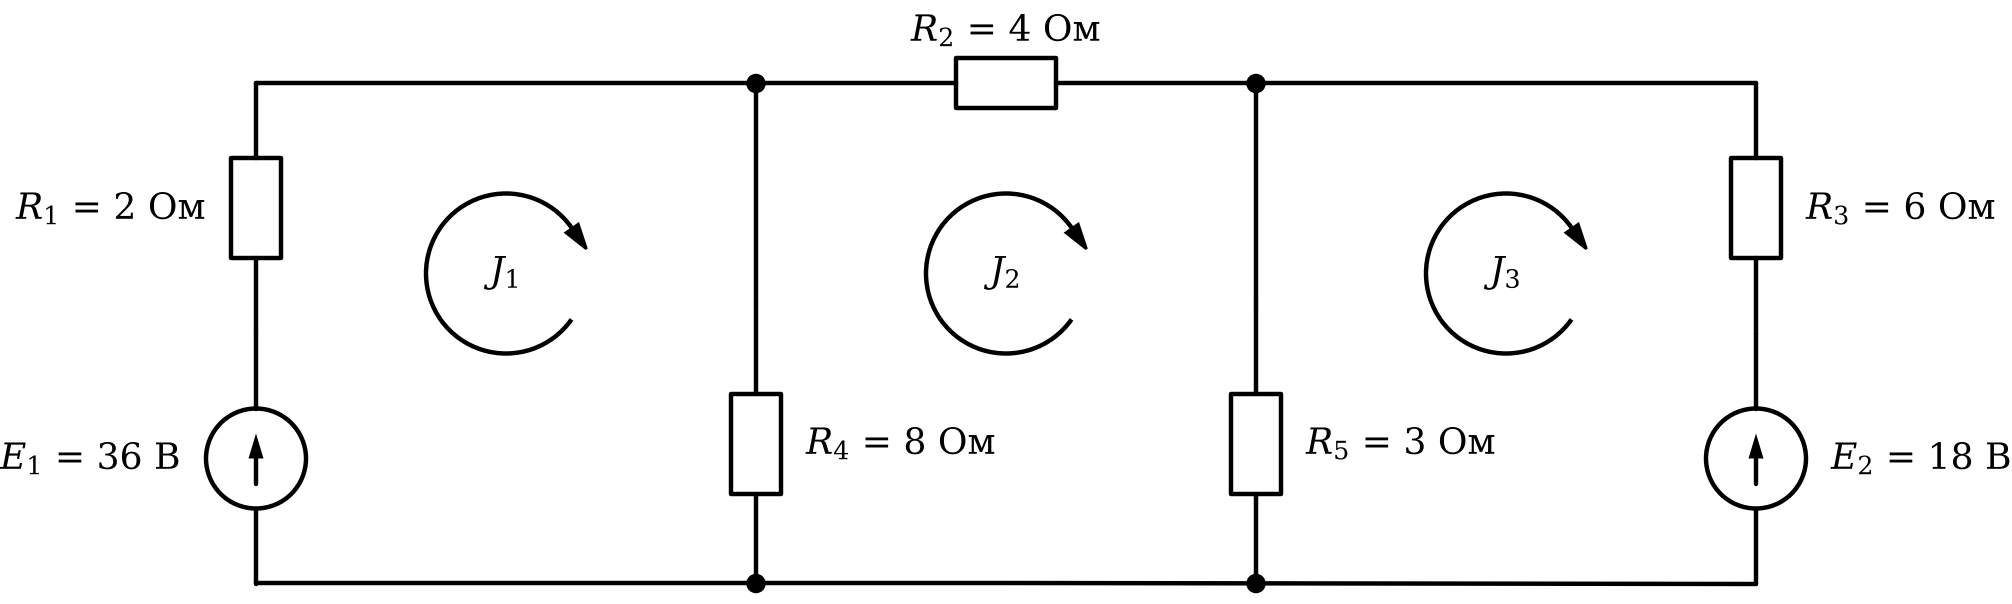

Контурные токи, А: [6.0, 3.0, -1.0]

Баланс мощностей **??**